In [ ]:
import os
import sys  

os.chdir('../..')
sys.path.append(os.getcwd())


In [ ]:
import json
from typing import List, Dict 


def extract_test_id_accuracy_per_ckpt(trainer_state_path: str, accuracy_key: str = "val/test_id/accuracy") -> List[Dict[str, float]]:
    with open(trainer_state_path, "r") as f:
        data = json.load(f)

    log_history = data.get("log_history", [])
    
    accuracy_data = []
    for entry in log_history:
        step = entry.get("step")
        if step is None:
            continue
        
        # Extract test ID accuracy (logged at checkpoint/eval steps)
        accuracy = entry.get(accuracy_key)
        if accuracy is not None:
            accuracy_data.append({
                "step": int(step),
                "accuracy": float(accuracy)
            })
    
    # Sort by step to ensure chronological order
    accuracy_data.sort(key=lambda x: x["step"])
    
    return accuracy_data


base_dir = 'scratch_data/training_outputs/'
ckpt_dir_dict = {
    'Lights-Out': {
        'Well-formed': "lights_out_exp_anonym_loc/incomplete_l8_h768_lr2e-5_bs8_wd0.1_ape_gn1_s{s}_ms50000_csa/", 
        'Conditional Effects': "lights_out_regular/default_l8_h768_lr2e-5_bs8_wd0.1_ape_s{s}_csa/", 
    },
    'Color Bags': {
        'Well-formed': "color_new_config/3_wf_l8_h768_lr3e-4_bs8_wd0.1_ape_s{s}",
        'STRIPS': "color_new_config/3_nwf_l8_h768_lr3e-4_bs8_wd0.1_ape_s{s}",
    },
    'Grippers': {
        'Well-formed': "grippers_new/3_wf_l8_h768_lr6e-4_bs8_wd0.1_ape_s{s}",
        'Delete-free': "grippers_new/3_df_l8_h768_lr6e-4_bs8_wd0.1_ape_s{s}",
    }
}


In [31]:
import pandas as pd

# Extract test ID accuracy for each checkpoint
df = []
for task in ckpt_dir_dict:
    for variant in ckpt_dir_dict[task]:
        for s in range(4):
            ckpt_dir = ckpt_dir_dict[task][variant].format(s=s)
            trainer_state_path = os.path.join(base_dir, ckpt_dir, "trainer_state.json")
            if not os.path.exists(trainer_state_path):
                continue
            
            accuracy_data = extract_test_id_accuracy_per_ckpt(trainer_state_path)
            for entry in accuracy_data:
                entry["task"] = task
                entry["variant"] = variant
                entry["s"] = s
                df.append(entry)

df = pd.DataFrame(df)
print(f"Dataframe shape: {df.shape}")
print(df.head())




Dataframe shape: (1200, 5)
   step  accuracy        task      variant  s
0  1000  0.507667  Lights-Out  Well-formed  0
1  2000  0.517083  Lights-Out  Well-formed  0
2  3000  0.546000  Lights-Out  Well-formed  0
3  4000  0.638750  Lights-Out  Well-formed  0
4  5000  0.857167  Lights-Out  Well-formed  0


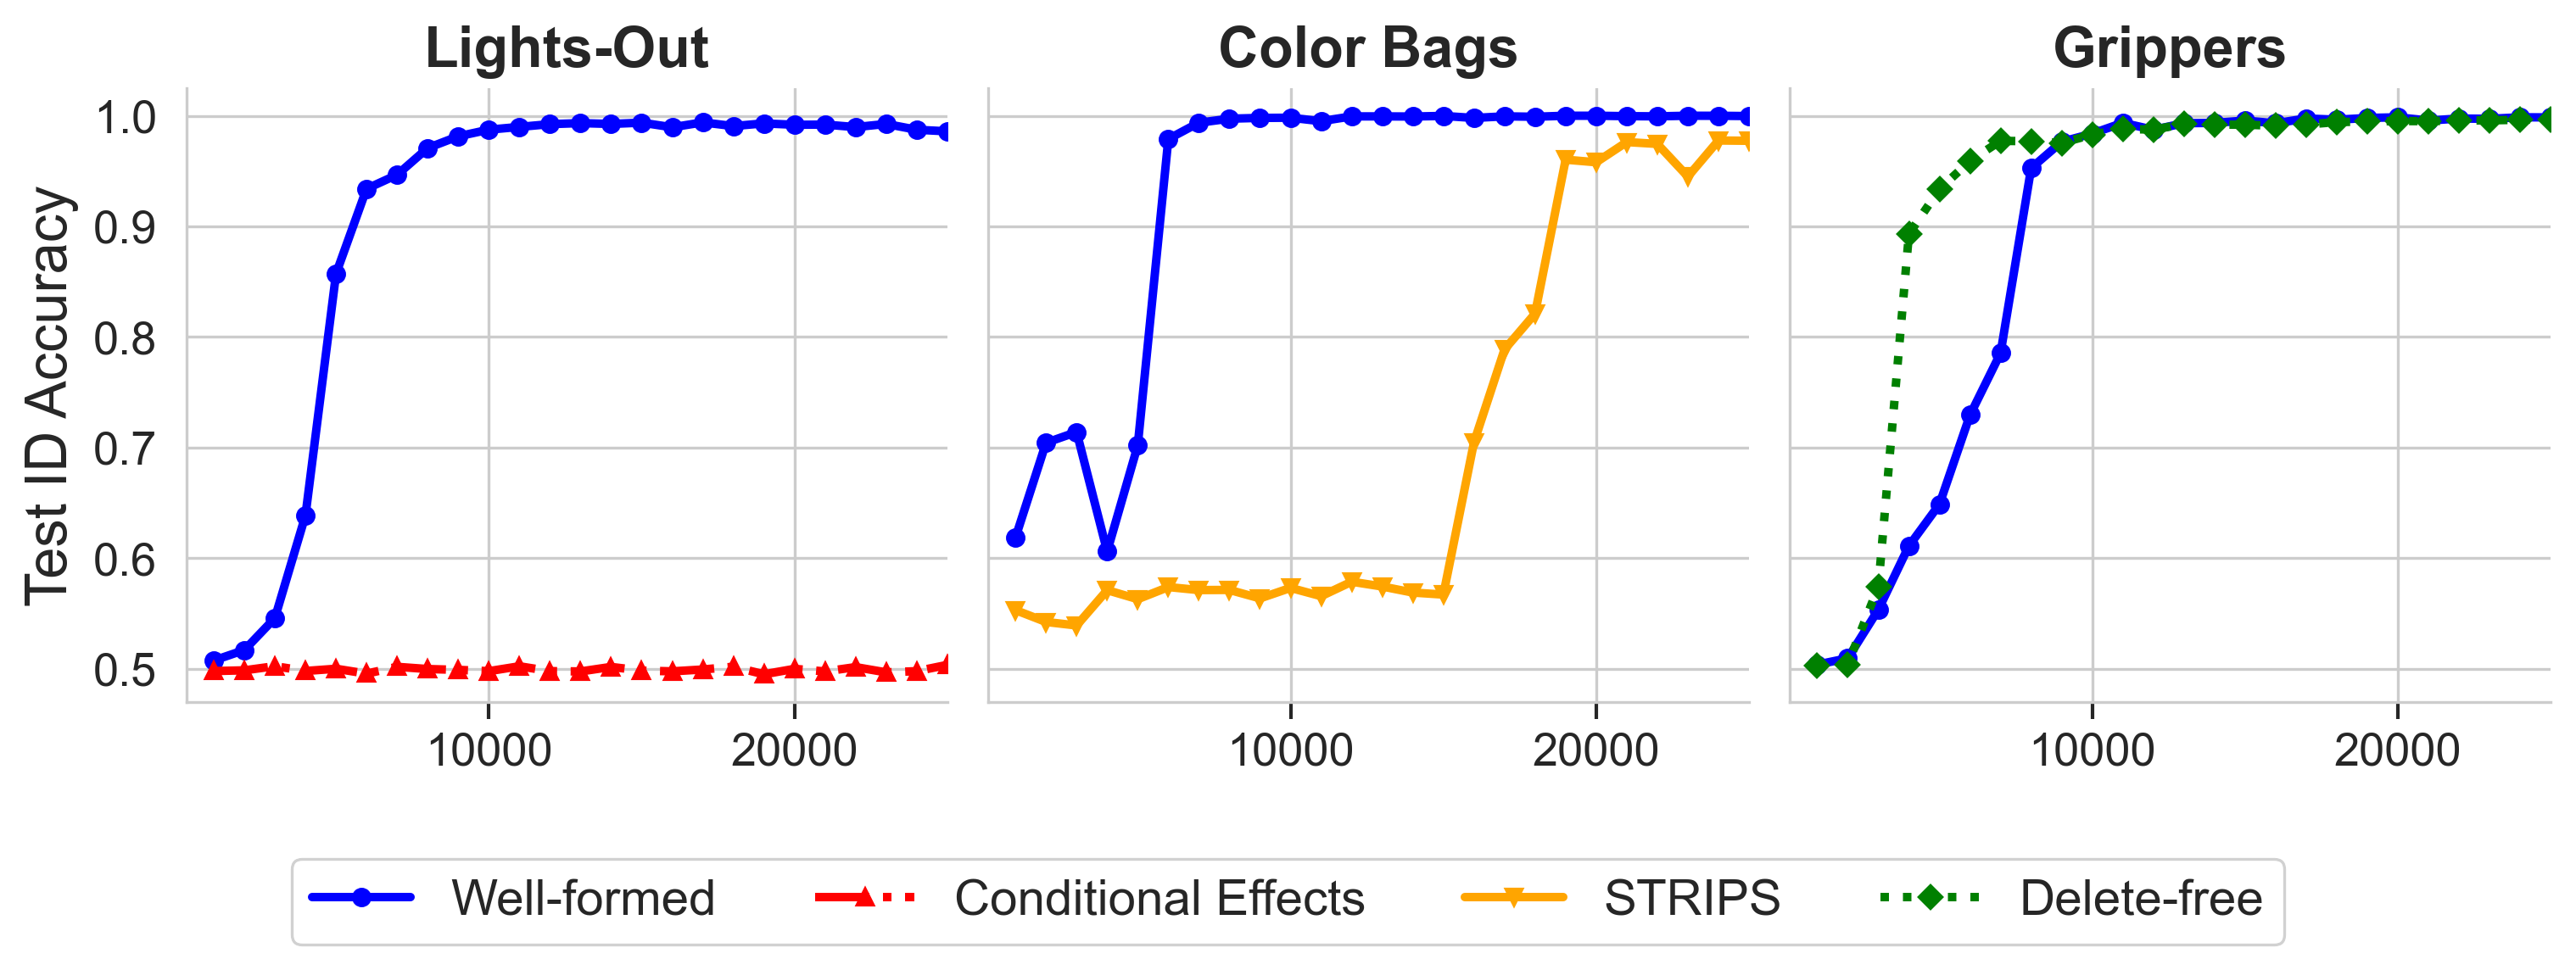

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------- Seaborn + NeurIPS-style dense formatting ----------------
sns.set_theme(
    context="paper",
    style="whitegrid",
    font="sans-serif",
    font_scale=2.0,   # larger base font
)
plt.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "legend.fontsize": 14,     # larger legend
        "legend.frameon": True,
        "legend.fancybox": True,
        "legend.edgecolor": "0.8",
        "legend.framealpha": 0.9,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 16,
    }
)

# ----- Variant styles -----
variant_styles = {
    "Well-formed":         {"color": "blue",   "marker": "o", "linestyle": "-",  "linewidth": 2.4},
    "Delete-free":         {"color": "green",  "marker": "D", "linestyle": ":",  "linewidth": 2.4},
    "Conditional Effects": {"color": "red",    "marker": "^", "linestyle": "-.", "linewidth": 2.4},
    "STRIPS":              {"color": "orange", "marker": "v", "linestyle": "-",  "linewidth": 2.4},
}

# Task → (variant1, variant2)
TASK_VARIANTS = {
    "Lights-Out": ("Well-formed", "Conditional Effects"),
    "Color Bags": ("Well-formed", "STRIPS"),
    "Grippers":   ("Well-formed", "Delete-free"),
}

seed = 0

# Narrower, denser NeurIPS-style strip figure
fig, axes = plt.subplots(1, 3, figsize=(10.5, 4), sharey=True)

for ax, (task, (v1, v2)) in zip(axes, TASK_VARIANTS.items()):
    task_df = df[(df["task"] == task) & (df["s"] == seed)].copy()
    if task_df.empty:
        ax.set_title(f"{task} (no data)")
        continue

    d1 = task_df[task_df["variant"] == v1].sort_values("step")
    d2 = task_df[task_df["variant"] == v2].sort_values("step")

    # Plot v1
    if not d1.empty:
        st = variant_styles[v1]
        ax.plot(
            d1["step"], d1["accuracy"],
            label=v1,
            color=st["color"],
            linestyle=st["linestyle"],
            marker=st["marker"],
            linewidth=st["linewidth"],
            markersize=4.5,
        )

    # Plot v2
    if not d2.empty:
        st = variant_styles[v2]
        ax.plot(
            d2["step"], d2["accuracy"],
            label=v2,
            color=st["color"],
            linestyle=st["linestyle"],
            marker=st["marker"],
            linewidth=st["linewidth"],
            markersize=4.5,
        )

    ax.set_title(task, fontweight="bold")

    ax.set_xlabel("")
    ax.set_xlim(100, 25000)
    # Add limited number of x-ticks (log style spread)
    x_ticks = [10000, 20000]
    ax.set_xticks(x_ticks)
    ax.tick_params(axis="x", which="both", bottom=True, labelbottom=True, labelsize=13)

# Shared Y label only
axes[0].set_ylabel("Test ID Accuracy")

# Global legend (big, readable)
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels:
            handles.append(hh)
            labels.append(ll)

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 0),
    frameon=True,
)

# Dense layout
fig.tight_layout(rect=[0, 0.12, 1, 1], w_pad=0.6)
plt.show()
